In [1]:
import numpy as np
import pandas as pd
import os
import torch

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cpu')

In [2]:
fname_train_old = "../experiments/datasets/RR/t10.4_t2.07_pipe/seed_0.train_100.csv"
fname_train_new = "../experiments/datasets/RR/t10.4_t2.07_pipe/seed_1.train_100.csv"
fname_test_old = "../experiments/datasets/RR/t10.4_t2.07_pipe/seed_0.test.csv"
fname_test_new = "../experiments/datasets/RR/t10.4_t2.07_pipe/seed_1.test.csv"

df_train_old = pd.read_csv(fname_train_old)
df_train_new = pd.read_csv(fname_train_new)
df_test_old = pd.read_csv(fname_test_old)
df_test_new = pd.read_csv(fname_test_new)

FileNotFoundError: [Errno 2] No such file or directory: '../experiments/datasets/RR/t10.4_t2.07_pipe/seed_0.train_100.csv'

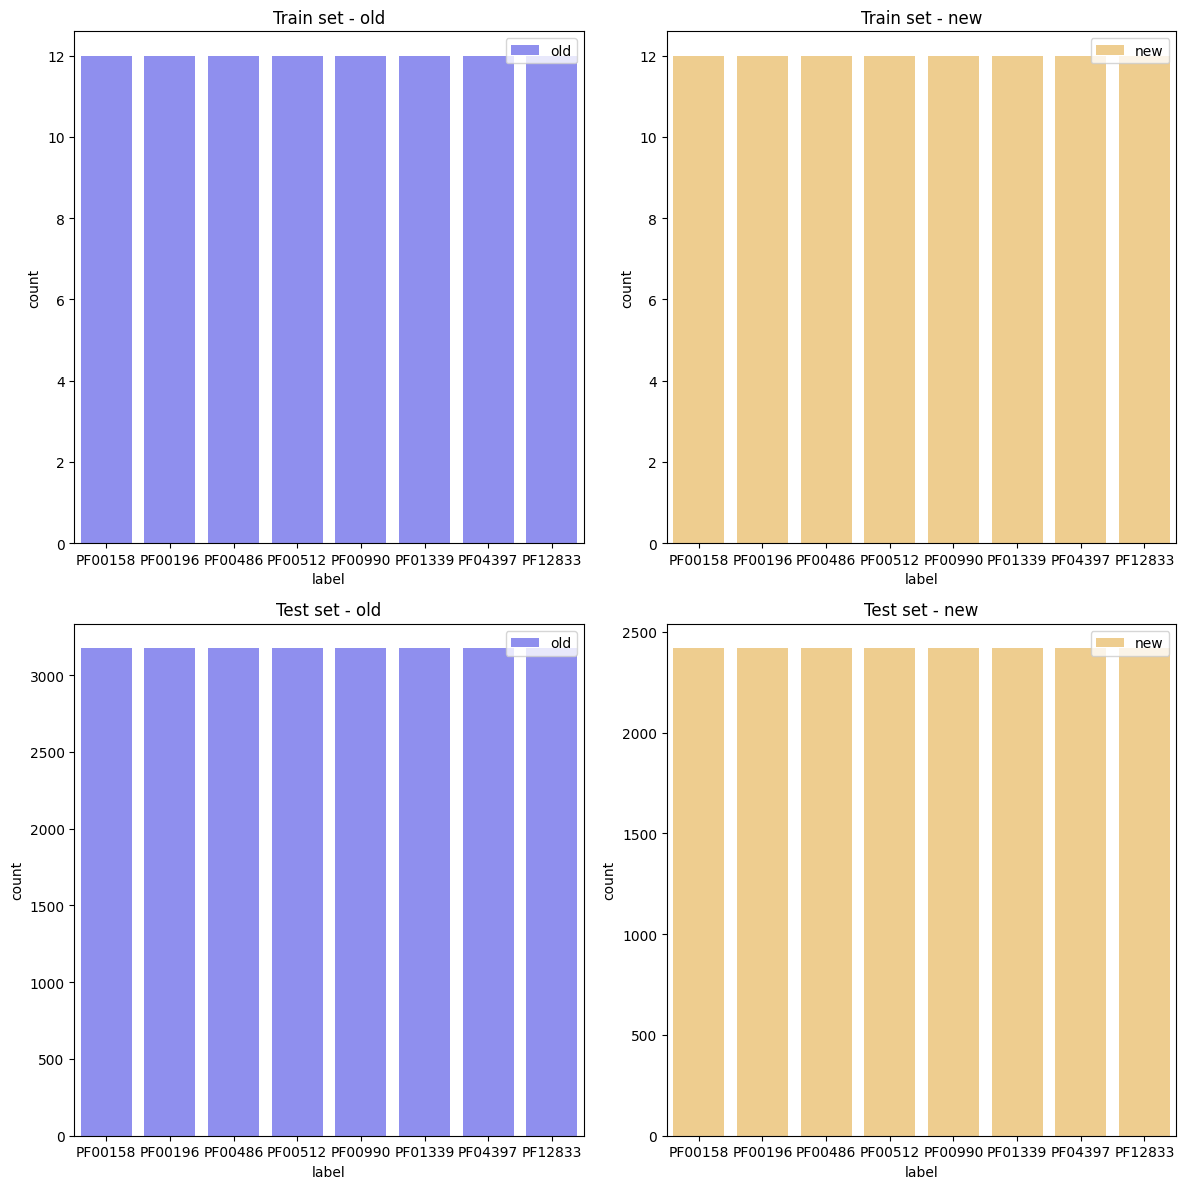

In [88]:
# barplot counting labels in train and test sets
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
sns.countplot(x="label", data=df_train_old, color="blue", alpha=0.5, label="old")
plt.title("Train set - old")
plt.subplot(2, 2, 2)
sns.countplot(x="label", data=df_train_new, color="orange", alpha=0.5, label="new")
plt.title("Train set - new")
plt.subplot(2, 2, 3)
sns.countplot(x="label", data=df_test_old, color="blue", alpha=0.5, label="old")
plt.title("Test set - old")
plt.subplot(2, 2, 4)
sns.countplot(x="label", data=df_test_new, color="orange", alpha=0.5, label="new")
plt.title("Test set - new")
plt.tight_layout()
plt.show()

## Check sequence distances

In [94]:
def get_max_seqids_intra(X: torch.Tensor):
    seqids = []
    L = X.shape[1]
    for i, x in enumerate(X):
        # exclude x from X
        X_excluded = torch.cat([X[:i], X[i+1:]], dim=0)
        sids = (x == X_excluded).sum(dim=-1) / L
        seqids.append(sids.max().item())
    return np.array(seqids).flatten()

def get_max_seqids_inter(X1: torch.Tensor, X2: torch.Tensor):
    seqids = []
    L = X1.shape[1]
    for x in X1:
        sids = (x == X2).sum(dim=-1) / L
        seqids.append(sids.max().item())
    return np.array(seqids).flatten()

In [90]:
import adabmDCA as dca
tokens = dca.get_tokens("protein")

In [91]:
X_train_old = df_train_old["sequence_align"].to_numpy()
X_train_old = dca.encode_sequence(X_train_old, tokens=tokens)
X_train_old = torch.tensor(X_train_old, dtype=torch.long, device="cuda")

X_test_old = df_test_old["sequence_align"].to_numpy()
X_test_old = dca.encode_sequence(X_test_old, tokens=tokens)
X_test_old = torch.tensor(X_test_old, dtype=torch.long, device="cuda")

X_train_new = df_train_new["sequence_align"].to_numpy()
X_train_new = dca.encode_sequence(X_train_new, tokens=tokens)
X_train_new = torch.tensor(X_train_new, dtype=torch.long, device="cuda")

X_test_new = df_test_new["sequence_align"].to_numpy()
X_test_new = dca.encode_sequence(X_test_new, tokens=tokens)
X_test_new = torch.tensor(X_test_new, dtype=torch.long, device="cuda")

In [96]:
print("Computing seqids for X_train_old...")
max_seqids_intra_train_old = get_max_seqids_intra(X_train_old)
print("Computing seqids for X_train_new...")
max_seqids_intra_train_new = get_max_seqids_intra(X_train_new)
print("Computing seqids for X_test_old...")
max_seqids_intra_test_old = get_max_seqids_intra(X_test_old)
print("Computing seqids for X_test_new...")
max_seqids_intra_test_new = get_max_seqids_intra(X_test_new)
print("Computing seqids for X_train_new and X_test_new...")
max_seqids_inter_train_new_test_new = get_max_seqids_inter(X_train_new, X_test_new)
print("Computing seqids for X_train_old and X_test_old...")
max_seqids_inter_train_old_test_old = get_max_seqids_inter(X_train_old, X_test_old)

Computing seqids for X_train_old...
Computing seqids for X_train_new...
Computing seqids for X_test_old...
Computing seqids for X_test_new...
Computing seqids for X_train_new and X_test_new...
Computing seqids for X_train_old and X_test_old...


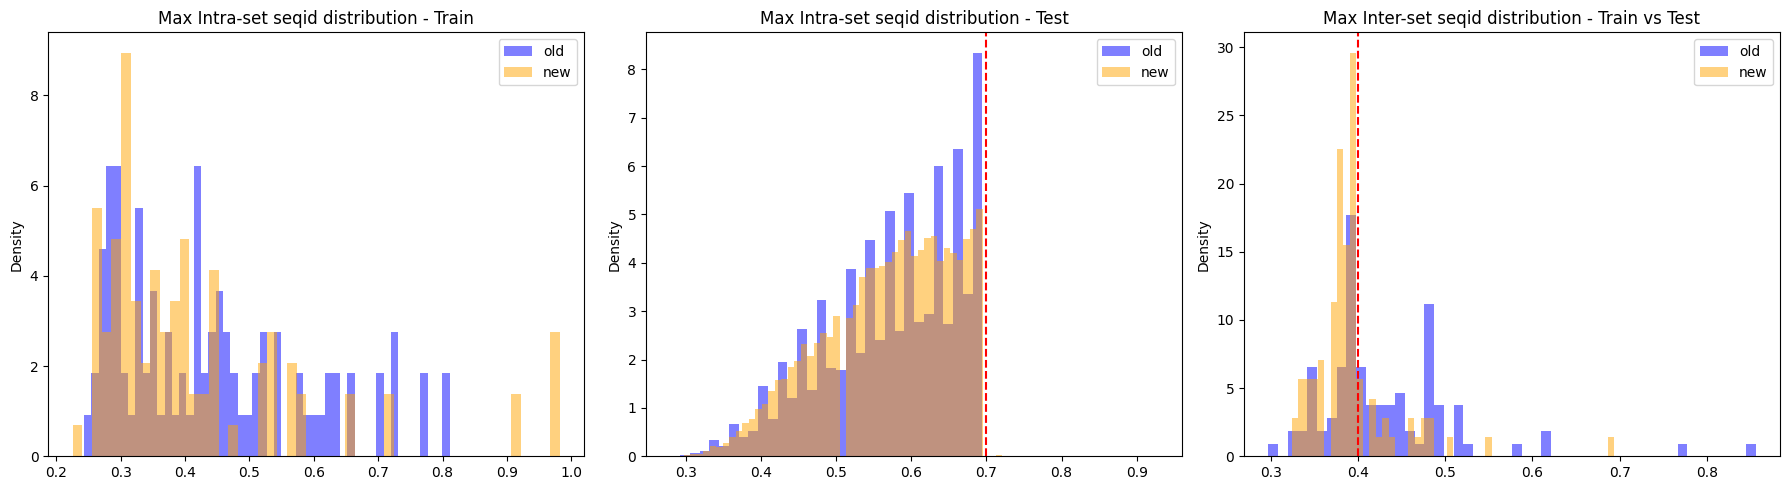

In [106]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# First column: Intra-set seqid distribution - Train
ax[0].hist(max_seqids_intra_train_old, bins=50, color="blue", alpha=0.5, label="old", density=True)
ax[0].hist(max_seqids_intra_train_new, bins=50, color="orange", alpha=0.5, label="new", density=True)
ax[0].set_title("Max Intra-set seqid distribution - Train")
ax[0].set_ylabel("Density")
#ax[0].set_yscale('log')
ax[0].legend()

# Second column: Intra-set seqid distribution - Test
ax[1].hist(max_seqids_intra_test_old, bins=50, color="blue", alpha=0.5, label="old", density=True)
ax[1].hist(max_seqids_intra_test_new, bins=50, color="orange", alpha=0.5, label="new", density=True)
ax[1].set_title("Max Intra-set seqid distribution - Test")
ax[1].set_ylabel("Density")
ax[1].axvline(x=0.7, color="red", linestyle="--")
#ax[1].set_yscale('log')
ax[1].legend()

# Third column: Inter-set seqid distribution
ax[2].hist(max_seqids_inter_train_old_test_old, bins=50, color="blue", alpha=0.5, label="old", density=True)
ax[2].hist(max_seqids_inter_train_new_test_new, bins=50, color="orange", alpha=0.5, label="new", density=True)
ax[2].set_title("Max Inter-set seqid distribution - Train vs Test")
ax[2].set_ylabel("Density")
ax[2].axvline(x=0.4, color="red", linestyle="--")
#ax[2].set_yscale('log')
ax[2].legend()

plt.tight_layout()
plt.show()


Computing max seqids for X_train_old_label...
Computing max seqids for X_test_old_label...
Computing max seqids for X_train_new_label...
Computing max seqids for X_test_new_label...
Computing max seqids for X_train_new_label and X_test_new_label...
Computing max seqids for X_train_old_label and X_test_old_label...
Computing max seqids for X_train_new_label...
Computing max seqids for X_test_new_label...
Computing max seqids for X_train_new_label and X_test_new_label...
Computing max seqids for X_train_old_label and X_test_old_label...


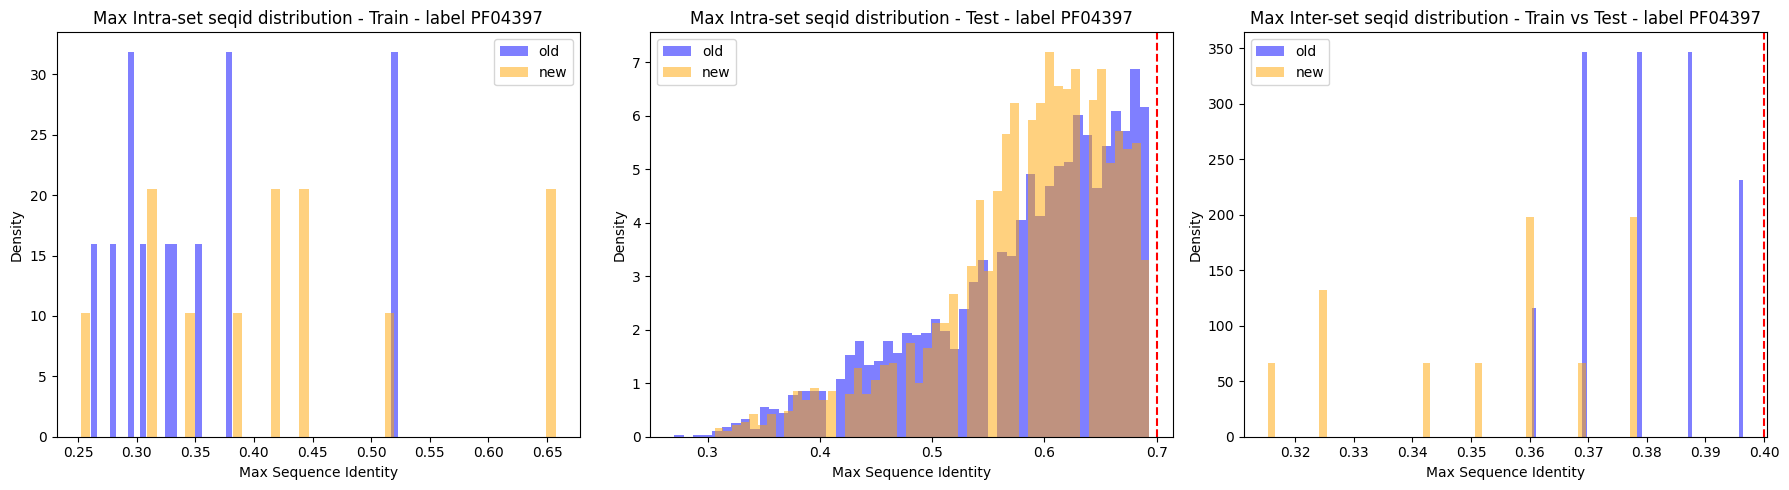

0.6576576828956604


In [108]:
# Select a specific label
labels = np.unique(df_train_new["label"].to_numpy())
label = labels[6]

X_train_old_label = df_train_old[df_train_old["label"] == label]["sequence_align"].to_numpy()
X_train_old_label = dca.encode_sequence(X_train_old_label, tokens=tokens)
X_train_old_label = torch.tensor(X_train_old_label, dtype=torch.long, device="cuda")

X_train_new_label = df_train_new[df_train_new["label"] == label]["sequence_align"].to_numpy()
X_train_new_label = dca.encode_sequence(X_train_new_label, tokens=tokens)
X_train_new_label = torch.tensor(X_train_new_label, dtype=torch.long, device="cuda")

X_test_old_label = df_test_old[df_test_old["label"] == label]["sequence_align"].to_numpy()
X_test_old_label = dca.encode_sequence(X_test_old_label, tokens=tokens)
X_test_old_label = torch.tensor(X_test_old_label, dtype=torch.long, device="cuda")

X_test_new_label = df_test_new[df_test_new["label"] == label]["sequence_align"].to_numpy()
X_test_new_label = dca.encode_sequence(X_test_new_label, tokens=tokens)
X_test_new_label = torch.tensor(X_test_new_label, dtype=torch.long, device="cuda")

print("Computing max seqids for X_train_old_label...")
max_seqids_intra_train_old_label = get_max_seqids_intra(X_train_old_label)
print("Computing max seqids for X_test_old_label...")
max_seqids_intra_test_old_label = get_max_seqids_intra(X_test_old_label)
print("Computing max seqids for X_train_new_label...")
max_seqids_intra_train_new_label = get_max_seqids_intra(X_train_new_label)
print("Computing max seqids for X_test_new_label...")
max_seqids_intra_test_new_label = get_max_seqids_intra(X_test_new_label)
print("Computing max seqids for X_train_new_label and X_test_new_label...")
max_seqids_inter_train_new_label_test_new_label = get_max_seqids_inter(X_train_new_label, X_test_new_label)
print("Computing max seqids for X_train_old_label and X_test_old_label...")
max_seqids_inter_train_old_label_test_old_label = get_max_seqids_inter(X_train_old_label, X_test_old_label)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# First column: Max Intra-set seqid distribution - Train
ax[0].hist(max_seqids_intra_train_old_label, bins=50, color="blue", alpha=0.5, label="old", density=True)
ax[0].hist(max_seqids_intra_train_new_label, bins=50, color="orange", alpha=0.5, label="new", density=True)
ax[0].set_title(f"Max Intra-set seqid distribution - Train - label {label}")
ax[0].set_ylabel("Density")
#ax[0].set_yscale('log')
ax[0].set_xlabel("Max Sequence Identity")
ax[0].legend()
# Second column: Max Intra-set seqid distribution - Test
ax[1].hist(max_seqids_intra_test_old_label, bins=50, color="blue", alpha=0.5, label="old", density=True)
ax[1].hist(max_seqids_intra_test_new_label, bins=50, color="orange", alpha=0.5, label="new", density=True)
ax[1].set_title(f"Max Intra-set seqid distribution - Test - label {label}")
ax[1].set_ylabel("Density")
ax[1].axvline(x=0.7, color="red", linestyle="--")
#ax[1].set_yscale('log')
ax[1].set_xlabel("Max Sequence Identity")
ax[1].legend()
# Third column: Max Inter-set seqid distribution
ax[2].hist(max_seqids_inter_train_old_label_test_old_label, bins=50, color="blue", alpha=0.5, label="old", density=True)
ax[2].hist(max_seqids_inter_train_new_label_test_new_label, bins=50, color="orange", alpha=0.5, label="new", density=True)
ax[2].set_title(f"Max Inter-set seqid distribution - Train vs Test - label {label}")
ax[2].set_ylabel("Density")
ax[2].set_xlabel("Max Sequence Identity")
ax[2].axvline(x=0.4, color="red", linestyle="--")
#ax[2].set_yscale('log')
ax[2].legend()

plt.tight_layout()
plt.show()

print(max_seqids_intra_train_new_label.max())

In [109]:
# Analyze all labels and collect results
labels = np.unique(df_train_new["label"].to_numpy())

results = {
    "label": [],
    "max_seqid_intra_train_old": [],
    "max_seqid_intra_train_new": [],
    "max_seqid_intra_test_old": [],
    "max_seqid_intra_test_new": [],
    "max_seqid_inter_train_test_old": [],
    "max_seqid_inter_train_test_new": []
}

for label in labels:
    print(f"Processing label: {label}")
    
    # Extract and encode sequences for this label
    X_train_old_label = df_train_old[df_train_old["label"] == label]["sequence_align"].to_numpy()
    X_train_old_label = dca.encode_sequence(X_train_old_label, tokens=tokens)
    X_train_old_label = torch.tensor(X_train_old_label, dtype=torch.long, device="cuda")
    
    X_train_new_label = df_train_new[df_train_new["label"] == label]["sequence_align"].to_numpy()
    X_train_new_label = dca.encode_sequence(X_train_new_label, tokens=tokens)
    X_train_new_label = torch.tensor(X_train_new_label, dtype=torch.long, device="cuda")
    
    X_test_old_label = df_test_old[df_test_old["label"] == label]["sequence_align"].to_numpy()
    X_test_old_label = dca.encode_sequence(X_test_old_label, tokens=tokens)
    X_test_old_label = torch.tensor(X_test_old_label, dtype=torch.long, device="cuda")
    
    X_test_new_label = df_test_new[df_test_new["label"] == label]["sequence_align"].to_numpy()
    X_test_new_label = dca.encode_sequence(X_test_new_label, tokens=tokens)
    X_test_new_label = torch.tensor(X_test_new_label, dtype=torch.long, device="cuda")
    
    # Compute max seqids
    max_intra_train_old = get_max_seqids_intra(X_train_old_label).max() if len(X_train_old_label) > 1 else 0
    max_intra_train_new = get_max_seqids_intra(X_train_new_label).max() if len(X_train_new_label) > 1 else 0
    max_intra_test_old = get_max_seqids_intra(X_test_old_label).max() if len(X_test_old_label) > 1 else 0
    max_intra_test_new = get_max_seqids_intra(X_test_new_label).max() if len(X_test_new_label) > 1 else 0
    max_inter_train_test_old = get_max_seqids_inter(X_train_old_label, X_test_old_label).max() if len(X_train_old_label) > 0 and len(X_test_old_label) > 0 else 0
    max_inter_train_test_new = get_max_seqids_inter(X_train_new_label, X_test_new_label).max() if len(X_train_new_label) > 0 and len(X_test_new_label) > 0 else 0
    
    # Store results
    results["label"].append(label)
    results["max_seqid_intra_train_old"].append(max_intra_train_old)
    results["max_seqid_intra_train_new"].append(max_intra_train_new)
    results["max_seqid_intra_test_old"].append(max_intra_test_old)
    results["max_seqid_intra_test_new"].append(max_intra_test_new)
    results["max_seqid_inter_train_test_old"].append(max_inter_train_test_old)
    results["max_seqid_inter_train_test_new"].append(max_inter_train_test_new)

# Convert to DataFrame
df_results = pd.DataFrame(results)
print("\nResults summary:")
print(df_results)

Processing label: PF00158
Processing label: PF00196
Processing label: PF00486
Processing label: PF00512
Processing label: PF00990
Processing label: PF01339
Processing label: PF04397
Processing label: PF12833

Results summary:
     label  max_seqid_intra_train_old  max_seqid_intra_train_new  \
0  PF00158                   0.765766                   0.972973   
1  PF00196                   0.549550                   0.513514   
2  PF00486                   0.810811                   0.981982   
3  PF00512                   0.450450                   0.450450   
4  PF00990                   0.468468                   0.396396   
5  PF01339                   0.720721                   0.540541   
6  PF04397                   0.522523                   0.657658   
7  PF12833                   0.702703                   0.909910   

   max_seqid_intra_test_old  max_seqid_intra_test_new  \
0                  0.693694                  0.693694   
1                  0.693694                  0.

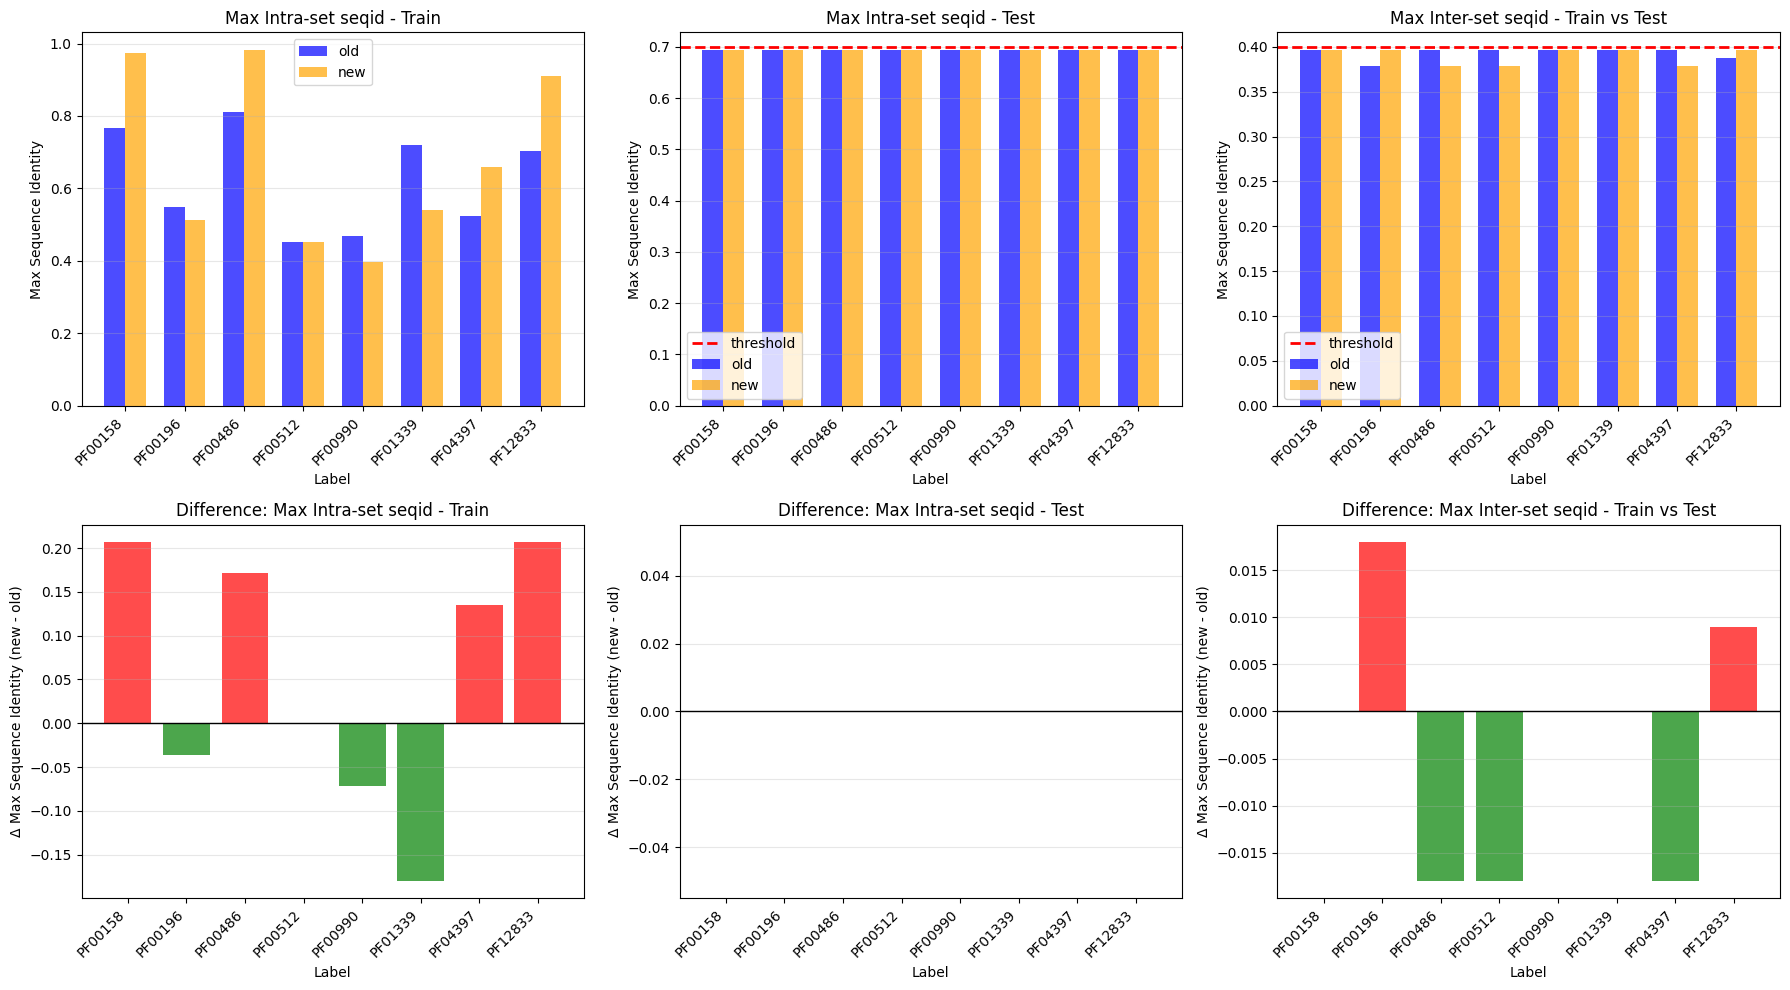

In [110]:
# Plot all results in a single figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Intra-set Train
ax = axes[0, 0]
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, df_results["max_seqid_intra_train_old"], width, label="old", color="blue", alpha=0.7)
ax.bar(x + width/2, df_results["max_seqid_intra_train_new"], width, label="new", color="orange", alpha=0.7)
ax.set_xlabel("Label")
ax.set_ylabel("Max Sequence Identity")
ax.set_title("Max Intra-set seqid - Train")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Intra-set Test
ax = axes[0, 1]
ax.bar(x - width/2, df_results["max_seqid_intra_test_old"], width, label="old", color="blue", alpha=0.7)
ax.bar(x + width/2, df_results["max_seqid_intra_test_new"], width, label="new", color="orange", alpha=0.7)
ax.axhline(y=0.7, color="red", linestyle="--", linewidth=2, label="threshold")
ax.set_xlabel("Label")
ax.set_ylabel("Max Sequence Identity")
ax.set_title("Max Intra-set seqid - Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Inter-set Train vs Test
ax = axes[0, 2]
ax.bar(x - width/2, df_results["max_seqid_inter_train_test_old"], width, label="old", color="blue", alpha=0.7)
ax.bar(x + width/2, df_results["max_seqid_inter_train_test_new"], width, label="new", color="orange", alpha=0.7)
ax.axhline(y=0.4, color="red", linestyle="--", linewidth=2, label="threshold")
ax.set_xlabel("Label")
ax.set_ylabel("Max Sequence Identity")
ax.set_title("Max Inter-set seqid - Train vs Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Comparison plots (difference between old and new)
ax = axes[1, 0]
diff_train = df_results["max_seqid_intra_train_new"] - df_results["max_seqid_intra_train_old"]
ax.bar(x, diff_train, color=["green" if d < 0 else "red" for d in diff_train], alpha=0.7)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Label")
ax.set_ylabel("Δ Max Sequence Identity (new - old)")
ax.set_title("Difference: Max Intra-set seqid - Train")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
diff_test = df_results["max_seqid_intra_test_new"] - df_results["max_seqid_intra_test_old"]
ax.bar(x, diff_test, color=["green" if d < 0 else "red" for d in diff_test], alpha=0.7)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Label")
ax.set_ylabel("Δ Max Sequence Identity (new - old)")
ax.set_title("Difference: Max Intra-set seqid - Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]
diff_inter = df_results["max_seqid_inter_train_test_new"] - df_results["max_seqid_inter_train_test_old"]
ax.bar(x, diff_inter, color=["green" if d < 0 else "red" for d in diff_inter], alpha=0.7)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Label")
ax.set_ylabel("Δ Max Sequence Identity (new - old)")
ax.set_title("Difference: Max Inter-set seqid - Train vs Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Comparison with multiple seeds

In [111]:
# Select 10 random seeds from 1 to 100
np.random.seed(42)  # For reproducibility
selected_seeds = np.random.choice(range(1, 101), size=10, replace=False)
selected_seeds = sorted(selected_seeds)
print(f"Selected seeds: {selected_seeds}")

# Load seed_0 (reference)
fname_train_ref = "../experiments/datasets/RR/t10.4_t2.07_pipe/seed_0.train_100.csv"
fname_test_ref = "../experiments/datasets/RR/t10.4_t2.07_pipe/seed_0.test.csv"
df_train_ref = pd.read_csv(fname_train_ref)
df_test_ref = pd.read_csv(fname_test_ref)

# Encode reference data
X_train_ref = df_train_ref["sequence_align"].to_numpy()
X_train_ref = dca.encode_sequence(X_train_ref, tokens=tokens)
X_train_ref = torch.tensor(X_train_ref, dtype=torch.long, device="cuda")

X_test_ref = df_test_ref["sequence_align"].to_numpy()
X_test_ref = dca.encode_sequence(X_test_ref, tokens=tokens)
X_test_ref = torch.tensor(X_test_ref, dtype=torch.long, device="cuda")

print("Computing max seqids for reference (seed_0)...")
ref_max_intra_train = get_max_seqids_intra(X_train_ref)
ref_max_intra_test = get_max_seqids_intra(X_test_ref)
ref_max_inter_train_test = get_max_seqids_inter(X_train_ref, X_test_ref)

Selected seeds: [np.int64(1), np.int64(11), np.int64(23), np.int64(40), np.int64(45), np.int64(46), np.int64(54), np.int64(71), np.int64(81), np.int64(84)]
Computing max seqids for reference (seed_0)...


In [112]:
# Collect data for all selected seeds
multi_seed_results = {
    "seed": [],
    "max_intra_train": [],
    "max_intra_test": [],
    "max_inter_train_test": []
}

# Store reference data
for val in ref_max_intra_train:
    multi_seed_results["seed"].append(0)
    multi_seed_results["max_intra_train"].append(val)
    multi_seed_results["max_intra_test"].append(np.nan)
    multi_seed_results["max_inter_train_test"].append(np.nan)

for val in ref_max_intra_test:
    multi_seed_results["seed"].append(0)
    multi_seed_results["max_intra_train"].append(np.nan)
    multi_seed_results["max_intra_test"].append(val)
    multi_seed_results["max_inter_train_test"].append(np.nan)

for val in ref_max_inter_train_test:
    multi_seed_results["seed"].append(0)
    multi_seed_results["max_intra_train"].append(np.nan)
    multi_seed_results["max_intra_test"].append(np.nan)
    multi_seed_results["max_inter_train_test"].append(val)

# Process each selected seed
for seed in selected_seeds:
    print(f"Processing seed {seed}...")
    fname_train = f"../experiments/datasets/RR/t10.4_t2.07_pipe/seed_{seed}.train_100.csv"
    fname_test = f"../experiments/datasets/RR/t10.4_t2.07_pipe/seed_{seed}.test.csv"
    
    df_train = pd.read_csv(fname_train)
    df_test = pd.read_csv(fname_test)
    
    X_train = df_train["sequence_align"].to_numpy()
    X_train = dca.encode_sequence(X_train, tokens=tokens)
    X_train = torch.tensor(X_train, dtype=torch.long, device="cuda")
    
    X_test = df_test["sequence_align"].to_numpy()
    X_test = dca.encode_sequence(X_test, tokens=tokens)
    X_test = torch.tensor(X_test, dtype=torch.long, device="cuda")
    
    max_intra_train = get_max_seqids_intra(X_train)
    max_intra_test = get_max_seqids_intra(X_test)
    max_inter_train_test = get_max_seqids_inter(X_train, X_test)
    
    # Store intra-train
    for val in max_intra_train:
        multi_seed_results["seed"].append(seed)
        multi_seed_results["max_intra_train"].append(val)
        multi_seed_results["max_intra_test"].append(np.nan)
        multi_seed_results["max_inter_train_test"].append(np.nan)
    
    # Store intra-test
    for val in max_intra_test:
        multi_seed_results["seed"].append(seed)
        multi_seed_results["max_intra_train"].append(np.nan)
        multi_seed_results["max_intra_test"].append(val)
        multi_seed_results["max_inter_train_test"].append(np.nan)
    
    # Store inter
    for val in max_inter_train_test:
        multi_seed_results["seed"].append(seed)
        multi_seed_results["max_intra_train"].append(np.nan)
        multi_seed_results["max_intra_test"].append(np.nan)
        multi_seed_results["max_inter_train_test"].append(val)

df_multi_seed = pd.DataFrame(multi_seed_results)
print(f"\nCollected {len(df_multi_seed)} data points across {len(selected_seeds) + 1} seeds")

Processing seed 1...
Processing seed 11...
Processing seed 23...
Processing seed 40...
Processing seed 45...
Processing seed 46...
Processing seed 54...
Processing seed 71...
Processing seed 81...
Processing seed 84...

Collected 243176 data points across 11 seeds


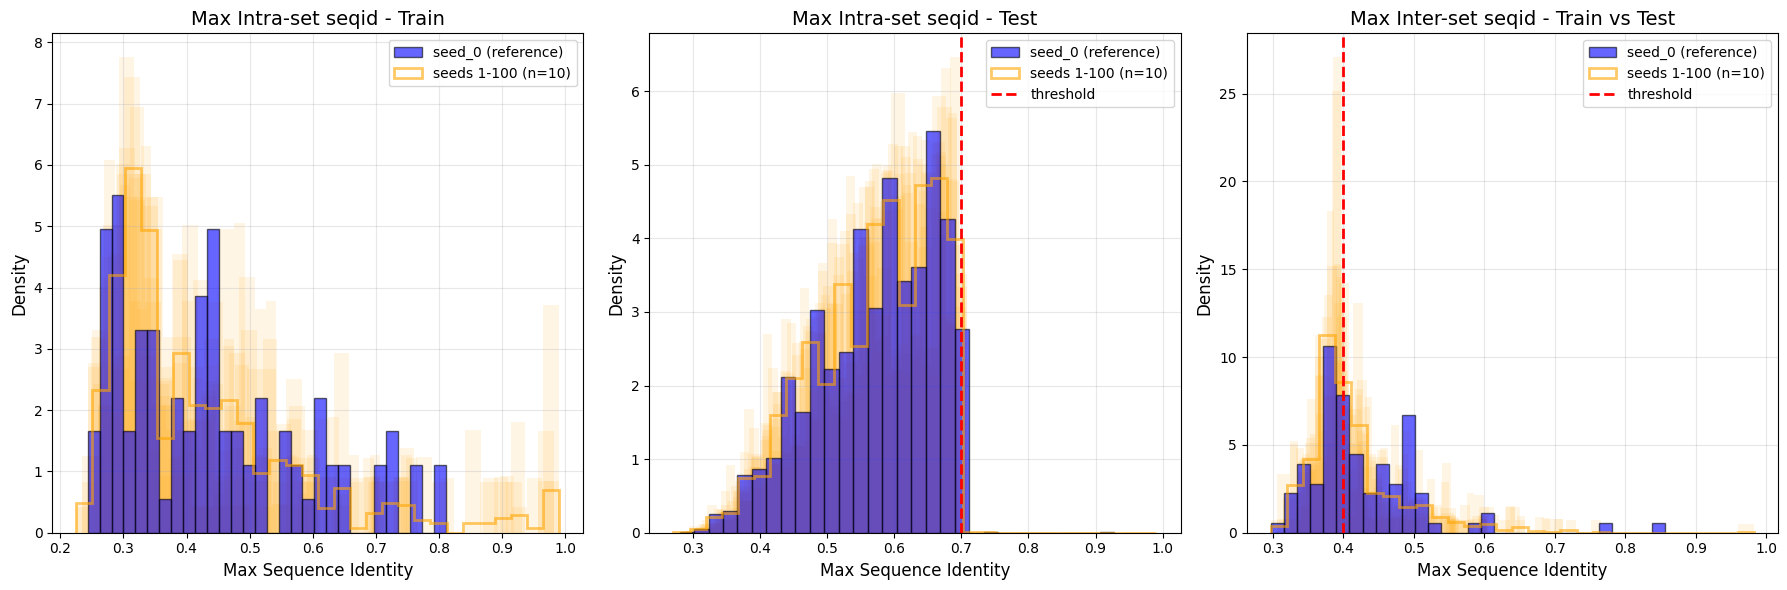

In [117]:
# Plot comparison: seed_0 vs typical seeds
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Intra-train
ax = axes[0]
# Plot seed_0 in blue
seed0_intra_train = df_multi_seed[df_multi_seed["seed"] == 0]["max_intra_train"].dropna()
ax.hist(seed0_intra_train, bins=30, color="blue", alpha=0.6, label="seed_0 (reference)", density=True, edgecolor='black', zorder=2)

# Plot other seeds in orange (overlaid)
for seed in selected_seeds:
    seed_data = df_multi_seed[df_multi_seed["seed"] == seed]["max_intra_train"].dropna()
    ax.hist(seed_data, bins=30, color="orange", alpha=0.1, density=True)

# Add a solid orange line for the average of other seeds
other_seeds_data = df_multi_seed[df_multi_seed["seed"] != 0]["max_intra_train"].dropna()
ax.hist(other_seeds_data, bins=30, color="orange", alpha=0.6, label=f"seeds 1-100 (n={len(selected_seeds)})", 
        density=True, histtype='step', linewidth=2)

ax.set_xlabel("Max Sequence Identity", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Max Intra-set seqid - Train", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Intra-test
ax = axes[1]
seed0_intra_test = df_multi_seed[df_multi_seed["seed"] == 0]["max_intra_test"].dropna()
ax.hist(seed0_intra_test, bins=30, color="blue", alpha=0.6, label="seed_0 (reference)", density=True, edgecolor='black', zorder=2)

for seed in selected_seeds:
    seed_data = df_multi_seed[df_multi_seed["seed"] == seed]["max_intra_test"].dropna()
    ax.hist(seed_data, bins=30, color="orange", alpha=0.1, density=True)

other_seeds_data = df_multi_seed[df_multi_seed["seed"] != 0]["max_intra_test"].dropna()
ax.hist(other_seeds_data, bins=30, color="orange", alpha=0.6, label=f"seeds 1-100 (n={len(selected_seeds)})", 
        density=True, histtype='step', linewidth=2)

ax.axvline(x=0.7, color="red", linestyle="--", linewidth=2, label="threshold")
ax.set_xlabel("Max Sequence Identity", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Max Intra-set seqid - Test", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Inter train-test
ax = axes[2]
seed0_inter = df_multi_seed[df_multi_seed["seed"] == 0]["max_inter_train_test"].dropna()
ax.hist(seed0_inter, bins=30, color="blue", alpha=0.6, label="seed_0 (reference)", density=True, edgecolor='black', zorder=2)

for seed in selected_seeds:
    seed_data = df_multi_seed[df_multi_seed["seed"] == seed]["max_inter_train_test"].dropna()
    ax.hist(seed_data, bins=30, color="orange", alpha=0.1, density=True)

other_seeds_data = df_multi_seed[df_multi_seed["seed"] != 0]["max_inter_train_test"].dropna()
ax.hist(other_seeds_data, bins=30, color="orange", alpha=0.6, label=f"seeds 1-100 (n={len(selected_seeds)})", 
        density=True, histtype='step', linewidth=2)

ax.axvline(x=0.4, color="red", linestyle="--", linewidth=2, label="threshold")
ax.set_xlabel("Max Sequence Identity", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Max Inter-set seqid - Train vs Test", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [118]:
# Summary statistics comparison
print("=" * 80)
print("SUMMARY STATISTICS: seed_0 vs typical seeds")
print("=" * 80)

metrics = [
    ("max_intra_train", "Max Intra-set seqid - Train"),
    ("max_intra_test", "Max Intra-set seqid - Test"),
    ("max_inter_train_test", "Max Inter-set seqid - Train vs Test")
]

for metric_col, metric_name in metrics:
    seed0_data = df_multi_seed[df_multi_seed["seed"] == 0][metric_col].dropna()
    other_data = df_multi_seed[df_multi_seed["seed"] != 0][metric_col].dropna()
    
    print(f"\n{metric_name}:")
    print(f"  seed_0:       mean={seed0_data.mean():.4f}, std={seed0_data.std():.4f}, max={seed0_data.max():.4f}")
    print(f"  typical:      mean={other_data.mean():.4f}, std={other_data.std():.4f}, max={other_data.max():.4f}")
    print(f"  Δ mean:       {other_data.mean() - seed0_data.mean():.4f}")
    print(f"  Δ max:        {other_data.max() - seed0_data.max():.4f}")

print("=" * 80)

SUMMARY STATISTICS: seed_0 vs typical seeds

Max Intra-set seqid - Train:
  seed_0:       mean=0.4404, std=0.1471, max=0.8108
  typical:      mean=0.4271, std=0.1604, max=0.9910
  Δ mean:       -0.0133
  Δ max:        0.1802

Max Intra-set seqid - Test:
  seed_0:       mean=0.5745, std=0.0883, max=0.9279
  typical:      mean=0.5711, std=0.0874, max=0.9910
  Δ mean:       -0.0034
  Δ max:        0.0631

Max Inter-set seqid - Train vs Test:
  seed_0:       mean=0.4306, std=0.0836, max=0.8559
  typical:      mean=0.4155, std=0.0680, max=0.9820
  Δ mean:       -0.0151
  Δ max:        0.1261


## Label-wise comparison with multiple seeds

In [119]:
# Analyze each label separately across multiple seeds
labels = np.unique(df_train_ref["label"].to_numpy())

label_wise_results = {
    "seed": [],
    "label": [],
    "max_intra_train": [],
    "max_intra_test": [],
    "max_inter_train_test": []
}

# Process seed_0 (reference)
print("Processing seed_0 (reference)...")
for label in labels:
    X_train_label = df_train_ref[df_train_ref["label"] == label]["sequence_align"].to_numpy()
    X_train_label = dca.encode_sequence(X_train_label, tokens=tokens)
    X_train_label = torch.tensor(X_train_label, dtype=torch.long, device="cuda")
    
    X_test_label = df_test_ref[df_test_ref["label"] == label]["sequence_align"].to_numpy()
    X_test_label = dca.encode_sequence(X_test_label, tokens=tokens)
    X_test_label = torch.tensor(X_test_label, dtype=torch.long, device="cuda")
    
    max_intra_train = get_max_seqids_intra(X_train_label).max() if len(X_train_label) > 1 else 0
    max_intra_test = get_max_seqids_intra(X_test_label).max() if len(X_test_label) > 1 else 0
    max_inter = get_max_seqids_inter(X_train_label, X_test_label).max() if len(X_train_label) > 0 and len(X_test_label) > 0 else 0
    
    label_wise_results["seed"].append(0)
    label_wise_results["label"].append(label)
    label_wise_results["max_intra_train"].append(max_intra_train)
    label_wise_results["max_intra_test"].append(max_intra_test)
    label_wise_results["max_inter_train_test"].append(max_inter)

# Process selected seeds
for seed in selected_seeds:
    print(f"Processing seed {seed}...")
    fname_train = f"../experiments/datasets/RR/t10.4_t2.07_pipe/seed_{seed}.train_100.csv"
    fname_test = f"../experiments/datasets/RR/t10.4_t2.07_pipe/seed_{seed}.test.csv"
    
    df_train = pd.read_csv(fname_train)
    df_test = pd.read_csv(fname_test)
    
    for label in labels:
        X_train_label = df_train[df_train["label"] == label]["sequence_align"].to_numpy()
        X_train_label = dca.encode_sequence(X_train_label, tokens=tokens)
        X_train_label = torch.tensor(X_train_label, dtype=torch.long, device="cuda")
        
        X_test_label = df_test[df_test["label"] == label]["sequence_align"].to_numpy()
        X_test_label = dca.encode_sequence(X_test_label, tokens=tokens)
        X_test_label = torch.tensor(X_test_label, dtype=torch.long, device="cuda")
        
        max_intra_train = get_max_seqids_intra(X_train_label).max() if len(X_train_label) > 1 else 0
        max_intra_test = get_max_seqids_intra(X_test_label).max() if len(X_test_label) > 1 else 0
        max_inter = get_max_seqids_inter(X_train_label, X_test_label).max() if len(X_train_label) > 0 and len(X_test_label) > 0 else 0
        
        label_wise_results["seed"].append(seed)
        label_wise_results["label"].append(label)
        label_wise_results["max_intra_train"].append(max_intra_train)
        label_wise_results["max_intra_test"].append(max_intra_test)
        label_wise_results["max_inter_train_test"].append(max_inter)

df_label_wise = pd.DataFrame(label_wise_results)
print(f"\nCollected {len(df_label_wise)} label-wise measurements across {len(selected_seeds) + 1} seeds")

Processing seed_0 (reference)...
Processing seed 1...
Processing seed 1...
Processing seed 11...
Processing seed 11...
Processing seed 23...
Processing seed 23...
Processing seed 40...
Processing seed 40...
Processing seed 45...
Processing seed 45...
Processing seed 46...
Processing seed 46...
Processing seed 54...
Processing seed 54...
Processing seed 71...
Processing seed 71...
Processing seed 81...
Processing seed 81...
Processing seed 84...
Processing seed 84...

Collected 88 label-wise measurements across 11 seeds

Collected 88 label-wise measurements across 11 seeds


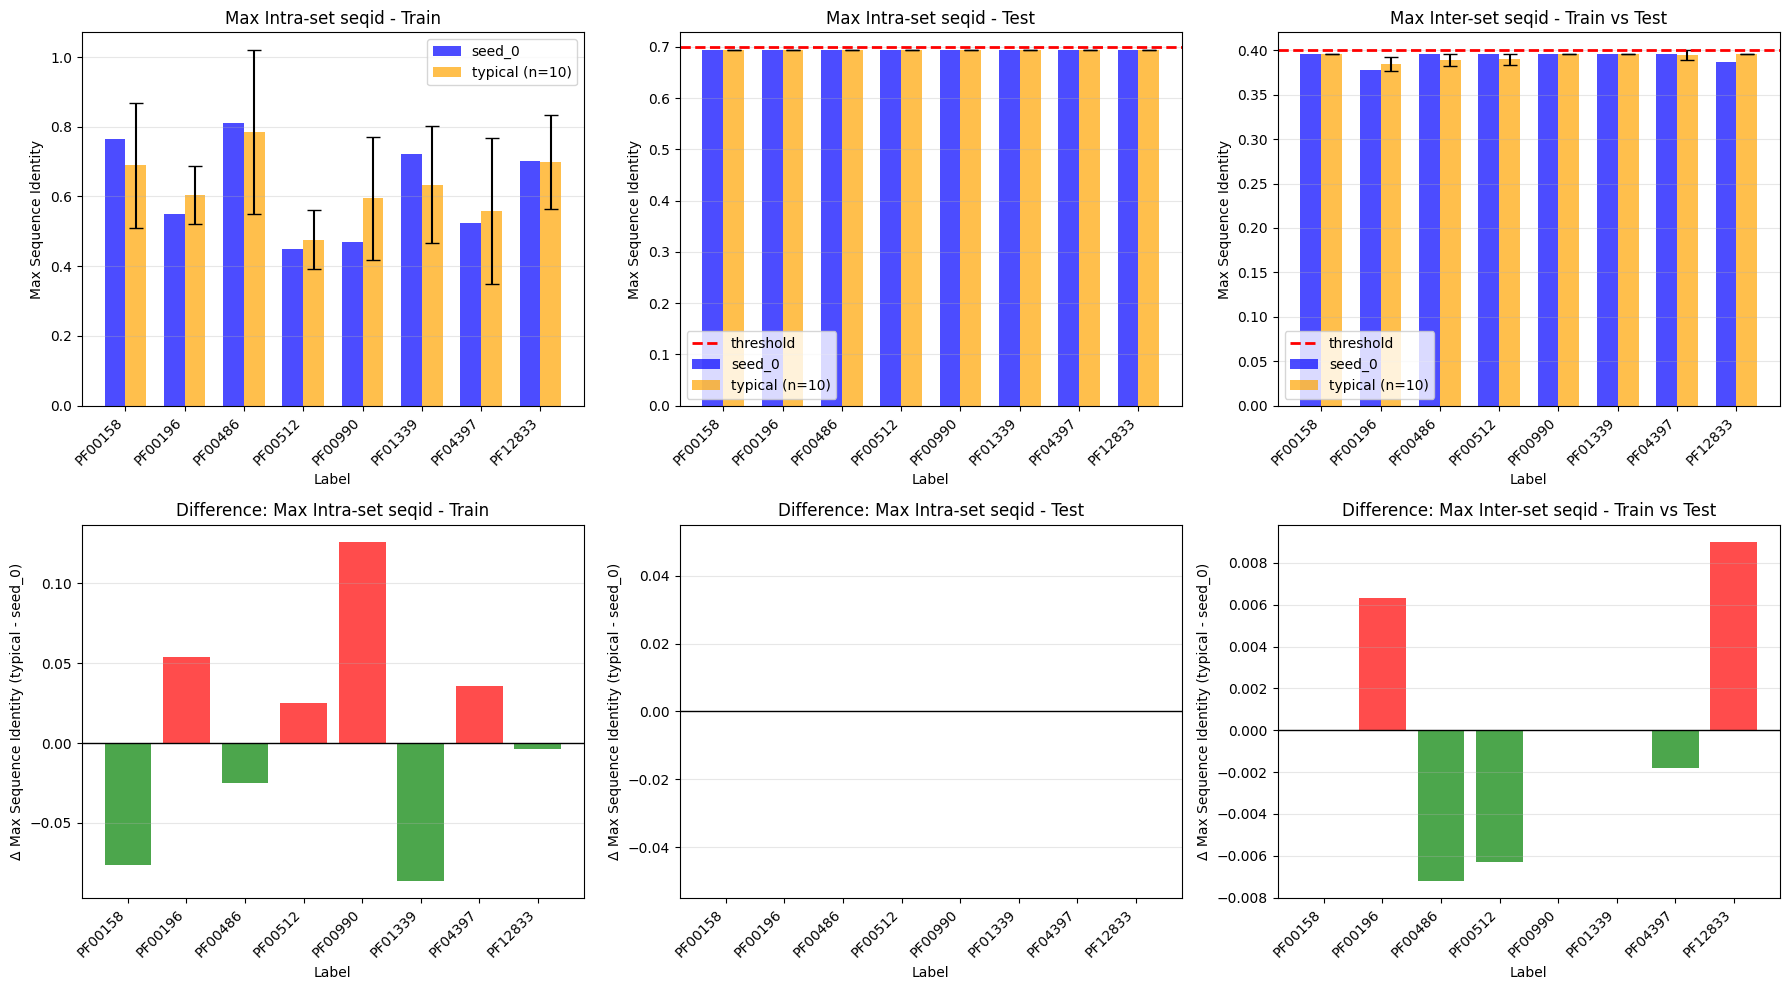

In [120]:
# Plot aggregated label-wise comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Prepare data
seed0_data = df_label_wise[df_label_wise["seed"] == 0]
other_seeds_data = df_label_wise[df_label_wise["seed"] != 0]

x = np.arange(len(labels))
width = 0.35

# Top row: Absolute values with error bars
# Intra-train
ax = axes[0, 0]
seed0_train = seed0_data.groupby("label")["max_intra_train"].mean()
other_train_mean = other_seeds_data.groupby("label")["max_intra_train"].mean()
other_train_std = other_seeds_data.groupby("label")["max_intra_train"].std()

ax.bar(x - width/2, seed0_train, width, label="seed_0", color="blue", alpha=0.7)
ax.bar(x + width/2, other_train_mean, width, yerr=other_train_std, 
       label=f"typical (n={len(selected_seeds)})", color="orange", alpha=0.7, capsize=5)
ax.set_xlabel("Label")
ax.set_ylabel("Max Sequence Identity")
ax.set_title("Max Intra-set seqid - Train")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Intra-test
ax = axes[0, 1]
seed0_test = seed0_data.groupby("label")["max_intra_test"].mean()
other_test_mean = other_seeds_data.groupby("label")["max_intra_test"].mean()
other_test_std = other_seeds_data.groupby("label")["max_intra_test"].std()

ax.bar(x - width/2, seed0_test, width, label="seed_0", color="blue", alpha=0.7)
ax.bar(x + width/2, other_test_mean, width, yerr=other_test_std, 
       label=f"typical (n={len(selected_seeds)})", color="orange", alpha=0.7, capsize=5)
ax.axhline(y=0.7, color="red", linestyle="--", linewidth=2, label="threshold")
ax.set_xlabel("Label")
ax.set_ylabel("Max Sequence Identity")
ax.set_title("Max Intra-set seqid - Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Inter-set
ax = axes[0, 2]
seed0_inter = seed0_data.groupby("label")["max_inter_train_test"].mean()
other_inter_mean = other_seeds_data.groupby("label")["max_inter_train_test"].mean()
other_inter_std = other_seeds_data.groupby("label")["max_inter_train_test"].std()

ax.bar(x - width/2, seed0_inter, width, label="seed_0", color="blue", alpha=0.7)
ax.bar(x + width/2, other_inter_mean, width, yerr=other_inter_std, 
       label=f"typical (n={len(selected_seeds)})", color="orange", alpha=0.7, capsize=5)
ax.axhline(y=0.4, color="red", linestyle="--", linewidth=2, label="threshold")
ax.set_xlabel("Label")
ax.set_ylabel("Max Sequence Identity")
ax.set_title("Max Inter-set seqid - Train vs Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Bottom row: Differences
ax = axes[1, 0]
diff_train = other_train_mean - seed0_train
ax.bar(x, diff_train, color=["green" if d < 0 else "red" for d in diff_train], alpha=0.7)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Label")
ax.set_ylabel("Δ Max Sequence Identity (typical - seed_0)")
ax.set_title("Difference: Max Intra-set seqid - Train")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
diff_test = other_test_mean - seed0_test
ax.bar(x, diff_test, color=["green" if d < 0 else "red" for d in diff_test], alpha=0.7)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Label")
ax.set_ylabel("Δ Max Sequence Identity (typical - seed_0)")
ax.set_title("Difference: Max Intra-set seqid - Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]
diff_inter = other_inter_mean - seed0_inter
ax.bar(x, diff_inter, color=["green" if d < 0 else "red" for d in diff_inter], alpha=0.7)
ax.axhline(y=0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Label")
ax.set_ylabel("Δ Max Sequence Identity (typical - seed_0)")
ax.set_title("Difference: Max Inter-set seqid - Train vs Test")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [121]:
# Summary table for label-wise comparison
print("=" * 100)
print("LABEL-WISE SUMMARY: seed_0 vs typical seeds")
print("=" * 100)
print(f"{'Label':<15} {'Metric':<25} {'seed_0':<10} {'typical':<15} {'Δ':<10}")
print("-" * 100)

for label in labels:
    seed0_label = df_label_wise[df_label_wise["seed"] == 0][df_label_wise["label"] == label]
    other_label = df_label_wise[df_label_wise["seed"] != 0][df_label_wise["label"] == label]
    
    metrics = [
        ("max_intra_train", "Train intra"),
        ("max_intra_test", "Test intra"),
        ("max_inter_train_test", "Train-Test inter")
    ]
    
    for metric_col, metric_name in metrics:
        seed0_val = seed0_label[metric_col].values[0]
        other_mean = other_label[metric_col].mean()
        other_std = other_label[metric_col].std()
        diff = other_mean - seed0_val
        
        if metric_col == metrics[0][0]:  # First metric for this label
            print(f"{label:<15} {metric_name:<25} {seed0_val:<10.4f} {other_mean:.4f}±{other_std:.4f}  {diff:>+.4f}")
        else:
            print(f"{'':15} {metric_name:<25} {seed0_val:<10.4f} {other_mean:.4f}±{other_std:.4f}  {diff:>+.4f}")
    print("-" * 100)

print("=" * 100)

LABEL-WISE SUMMARY: seed_0 vs typical seeds
Label           Metric                    seed_0     typical         Δ         
----------------------------------------------------------------------------------------------------
PF00158         Train intra               0.7658     0.6892±0.1797  -0.0766
                Test intra                0.6937     0.6937±0.0000  +0.0000
                Train-Test inter          0.3964     0.3964±0.0000  +0.0000
----------------------------------------------------------------------------------------------------
PF00196         Train intra               0.5495     0.6036±0.0830  +0.0541
                Test intra                0.6937     0.6937±0.0000  +0.0000
                Train-Test inter          0.3784     0.3847±0.0074  +0.0063
----------------------------------------------------------------------------------------------------
PF00486         Train intra               0.8108     0.7856±0.2345  -0.0252
                Test intra               

/tmp/ipykernel_1984114/1170381727.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seed0_label = df_label_wise[df_label_wise["seed"] == 0][df_label_wise["label"] == label]
/tmp/ipykernel_1984114/1170381727.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  other_label = df_label_wise[df_label_wise["seed"] != 0][df_label_wise["label"] == label]
/tmp/ipykernel_1984114/1170381727.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seed0_label = df_label_wise[df_label_wise["seed"] == 0][df_label_wise["label"] == label]
/tmp/ipykernel_1984114/1170381727.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  other_label = df_label_wise[df_label_wise["seed"] != 0][df_label_wise["label"] == label]
/tmp/ipykernel_1984114/1170381727.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  seed0_label = df_label_wise[df_label_wise["seed"] ==